In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_csv(r"C:\Users\LATITUDE\Documents\GitHub\AI4I-Predictive-Maintenance\Data\Raw\ai4i2020.csv")
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [44]:
df['Diff temperature'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Power'] = df['Rotational speed [rpm]'] * df['Torque [Nm]']

In [45]:
df.drop(columns=['UDI'], inplace=True)
df.drop(columns = ['Product ID'], inplace = True)

In [46]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Diff temperature,Power
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0


In [47]:
features = ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Diff temperature', 'Power']

x = df[features]

y = df['Machine failure']

In [48]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
                                                    x, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state=42,
                                                    stratify=y
                                                    )

In [49]:
print("Training set:", x_train.shape)
print("Test set:", x_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)
print()
print('Good- both splits have roughly the same machine failure rate')

Training set: (8000, 8)
Test set: (2000, 8)

Training target distribution:
Machine failure
0    96.6125
1     3.3875
Name: proportion, dtype: float64

Test target distribution:
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64

Good- both splits have roughly the same machine failure rate


In [50]:
x.dtypes
#y.dtypes

Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Diff temperature           float64
Power                      float64
dtype: object

In [51]:
y.dtypes

dtype('int64')

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


In [53]:
numerical_features = [
                    'Air temperature [K]', 
                    'Process temperature [K]',
                    'Rotational speed [rpm]', 
                    'Torque [Nm]', 
                    'Tool wear [min]', 
                    'Diff temperature', 
                    'Power'
                    ]

categorical_features = ['Type']

numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)


categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor defined.")
print("Numeric pipeline:", [s[0] for s in numerical_transformer.steps])
print("Categorical pipeline:", [s[0] for s in categorical_transformer.steps])

Preprocessor defined.
Numeric pipeline: ['scaler']
Categorical pipeline: ['onehot']


In [54]:
x_train_processed = preprocessor.fit_transform(x_train)


print("Before preprocessing:", x_train.shape)
print("After preprocessing:", x_train_processed.shape)


Before preprocessing: (8000, 8)
After preprocessing: (8000, 10)


In [55]:
x_test_processed = preprocessor.transform(x_test)
print("Before preprocessing:", x_test.shape)
print("After preprocessing:", x_test_processed.shape)


Before preprocessing: (2000, 8)
After preprocessing: (2000, 10)


In [83]:
from sklearn.linear_model import LogisticRegression

#logreg = LogisticRegression(
  #  max_iter=1000,
   # random_state=42
# when we say baseline we mean the simplest model we can use to get a sense of how well
# our features can predict the target variable. In this case, we are using logistic regression
# as our baseline model.)

baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression( max_iter=1000,random_state=42))
])

baseline_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Type','Air temperature [K]','Process temperature [K]',..., 'Tool wear [min]','Diff temperature','Power']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

In [86]:
y_pred_lr = baseline_pipeline.predict(x_test)
y_prob_lr = baseline_pipeline.predict_proba(x_test)[:, 1]

In [ ]:
lr_model = baseline_pipeline.named_steps['model']
lr_model.coef_

array([[ 0.25261297, -0.08832794,  2.18101375,  5.19810312,  0.82386079,
        -0.6351965 , -2.34617184, -0.23280258,  0.36999229, -0.13901062]])

([<matplotlib.axis.XTick at 0x15e60a899d0>,
 [Text(0, 0, 'Air temperature [K]'),
  Text(1, 0, 'Process temperature [K]'),
  Text(2, 0, 'Rotational speed [rpm]'),
  Text(3, 0, 'Torque [Nm]'),
  Text(4, 0, 'Tool wear [min]'),
  Text(5, 0, 'Diff temperature'),
  Text(6, 0, 'Power'),
  Text(7, 0, 'Type_H'),
  Text(8, 0, 'Type_L'),
  Text(9, 0, 'Type_M')])

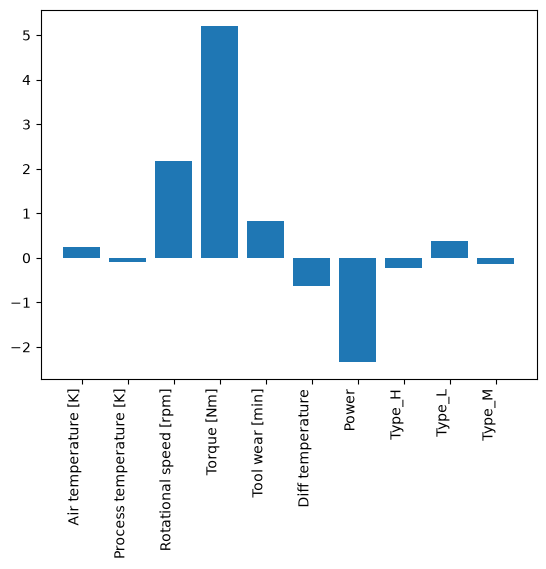

In [96]:
plt.bar(x= range(len(lr_model.coef_[0])), height=lr_model.coef_[0])
labels = preprocessor.get_feature_names_out()
labels = [label.replace("num__", "").replace("cat__", "") for label in labels]
plt.xticks(range(len(labels)), labels, rotation=90, ha='right')

In [87]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

In [91]:
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Logistic Regression Precision: {precision_score(y_test, y_pred_lr):.3f}")
print(f"Logistic Regression Recall: {recall_score(y_test, y_pred_lr):.3f}")
print(f"Logistic Regression F1-Score: {f1_score(y_test, y_pred_lr):.3f}")
print(f"Logistic Regression AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.3f}")

Logistic Regression Accuracy: 0.9675
Logistic Regression Precision: 0.571
Logistic Regression Recall: 0.176
Logistic Regression F1-Score: 0.270
Logistic Regression AUC-ROC: 0.926


<Figure size 800x600 with 0 Axes>

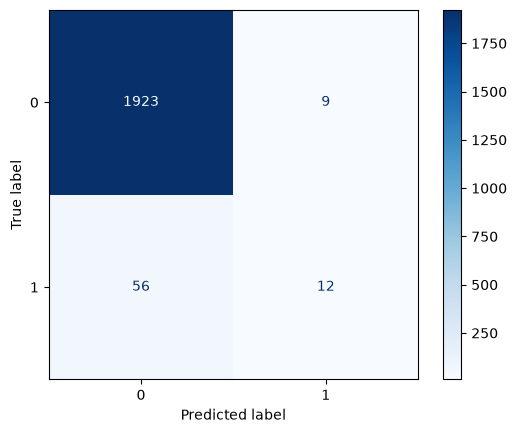

In [99]:
confusion_mtx = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mtx, display_labels=baseline_pipeline.classes_)
disp.plot(cmap=plt.cm.Blues, values_format='d')


In [100]:
LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [101]:
balanced_baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression( class_weight='balanced', 
                                 max_iter=1000,
                                 random_state=42))
])

balanced_baseline_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Type','Air temperature [K]','Process temperature [K]',..., 'Tool wear [min]','Diff temperature','Power']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

In [102]:
y_pred_balanced = balanced_baseline_pipeline.predict(x_test)
y_prob_balanced = balanced_baseline_pipeline.predict_proba(x_test)[:, 1]

In [103]:
print(f"Balanced Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_balanced):.4f}")
print(f"Balanced Logistic Regression Precision: {precision_score(y_test, y_pred_balanced):.3f}")
print(f"Balanced Logistic Regression Recall: {recall_score(y_test, y_pred_balanced):.3f}")
print(f"Balanced Logistic Regression F1-Score: {f1_score(y_test, y_pred_balanced):.3f}")
print(f"Balanced Logistic Regression AUC-ROC: {roc_auc_score(y_test, y_prob_balanced):.3f}")

Balanced Logistic Regression Accuracy: 0.8585
Balanced Logistic Regression Precision: 0.177
Balanced Logistic Regression Recall: 0.868
Balanced Logistic Regression F1-Score: 0.294
Balanced Logistic Regression AUC-ROC: 0.934


In [ ]:
confusion_mtx = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mtx, display_labels=baseline_pipeline.classes_)
disp.plot(cmap=plt.cm.Blues, values_format='d')
